In [1]:
# ============================================
# CELL 1: Mount Google Drive & Setup
# ============================================
from google.colab import drive
drive.mount('/content/drive')

# Create workspace
!mkdir -p /content/leaf_classification
!mkdir -p /content/leaf_classification/checkpoints
!mkdir -p /content/leaf_classification/logs

import os
os.chdir('/content/leaf_classification')

print("✓ Google Drive mounted")
print("✓ Workspace created")

Mounted at /content/drive
✓ Google Drive mounted
✓ Workspace created


In [2]:
# ============================================
# CELL 2: Install Dependencies
# ============================================
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q opencv-python-headless pillow numpy scikit-learn tqdm matplotlib seaborn albumentations

print("✓ All packages installed")

✓ All packages installed


In [3]:
# ============================================
# CELL 3: Configuration
# ============================================
import torch
import os

class Config:
    # Update this path to your dataset location in Google Drive
    DATASET_PATH = "/content/drive/MyDrive/Refine_Dataset"  # CHANGE THIS

    # Model parameters
    NUM_CLASSES = 30  # Number of species
    INPUT_SIZE = 224  # Reduced for faster training in Colab (was 512)
    BATCH_SIZE = 64   # Adjust based on Colab GPU memory
    NUM_EPOCHS = 50   # Can increase if needed
    #For Resnet50
    #LEARNING_RATE = 0.005
    #For Resnet layer1 and 2
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-5

    # Texture emphasis parameters
    TEXTURE_ALPHA = 0.0
    USE_MIXUP = False
    MIXUP_ALPHA = 0.2

    # Training
    NUM_WORKERS = 2
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42

    # Checkpointing
    SAVE_DIR = "/content/leaf_classification/checkpoints"
    LOG_DIR = "/content/leaf_classification/logs"

config = Config()

print(f"✓ Configuration loaded")
print(f"✓ Device: {config.DEVICE}")
print(f"✓ Dataset path: {config.DATASET_PATH}")
print(f"✓ Number of classes: {config.NUM_CLASSES}")

✓ Configuration loaded
✓ Device: cuda
✓ Dataset path: /content/drive/MyDrive/Refine_Dataset
✓ Number of classes: 30


In [4]:
# ============================================
# CELL 4: Data Preparation (Split dataset if needed)
# ============================================
import os
import shutil
import random
from sklearn.model_selection import train_test_split

def prepare_dataset(source_path, target_path, train_ratio=0.6, val_ratio=0.25, test_ratio=0.15):
    """
    Split dataset into train/val/test if not already split
    Assumes structure: source_path/class_name/*.jpg
    """

    if os.path.exists(os.path.join(target_path, 'train')):
        print("✓ Dataset already split! Using existing splits.")
        return

    print("📁 Splitting dataset into train/val/test...")

    # Get all classes
    classes = [d for d in os.listdir(source_path)
               if os.path.isdir(os.path.join(source_path, d))]

    # Create directories
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(target_path, split), exist_ok=True)

    # Split each class
    for class_name in classes:
        class_path = os.path.join(source_path, class_name)
        images = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]

        # Split
        train_imgs, temp_imgs = train_test_split(images, train_size=train_ratio, random_state=42)
        val_imgs, test_imgs = train_test_split(temp_imgs,
                                               train_size=val_ratio/(val_ratio+test_ratio),
                                               random_state=42)

        # Create class directories in each split
        for split, imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
            os.makedirs(os.path.join(target_path, split, class_name), exist_ok=True)
            for img in imgs:
                shutil.copy2(
                    os.path.join(class_path, img),
                    os.path.join(target_path, split, class_name, img)
                )

        print(f"  ✓ {class_name}: Train={len(train_imgs)}, Val={len(val_imgs)}, Test={len(test_imgs)}")

    print(f"✓ Dataset split complete! Saved to {target_path}")

# Run the split
SPLIT_PATH = "/content/leaf_classification/split_dataset"

# Update config with split paths
config.TRAIN_PATH = os.path.join(SPLIT_PATH, 'train')
config.VAL_PATH = os.path.join(SPLIT_PATH, 'val')
config.TEST_PATH = os.path.join(SPLIT_PATH, 'test')

# Prepare dataset (only runs once)
prepare_dataset(config.DATASET_PATH, SPLIT_PATH)

📁 Splitting dataset into train/val/test...
  ✓ 9.Sofeda: Train=60, Val=25, Test=15
  ✓ 7.Daruchini: Train=60, Val=25, Test=15
  ✓ 8.Tejpata: Train=60, Val=25, Test=15
  ✓ 5.Goolmorich: Train=60, Val=25, Test=15
  ✓ 4.Hatishur: Train=60, Val=25, Test=15
  ✓ 6.Togor: Train=60, Val=25, Test=15
  ✓ 30.Orjun: Train=60, Val=25, Test=15
  ✓ 3.Bashok: Train=60, Val=25, Test=15
  ✓ 29.Hasnahena: Train=60, Val=25, Test=15
  ✓ 26.Akondo: Train=60, Val=25, Test=15
  ✓ 27.Karipata: Train=60, Val=25, Test=15
  ✓ 28.Oporajita: Train=60, Val=25, Test=15
  ✓ 25.Raktapata: Train=60, Val=25, Test=15
  ✓ 23.Lemon: Train=60, Val=25, Test=15
  ✓ 24.Dhutra: Train=60, Val=25, Test=15
  ✓ 22.Paharipata: Train=60, Val=25, Test=15
  ✓ 21.Thankuni: Train=60, Val=25, Test=15
  ✓ 19.Aorhor: Train=60, Val=25, Test=15
  ✓ 18.Mehedi: Train=60, Val=25, Test=15
  ✓ 20.Pudina: Train=60, Val=25, Test=15
  ✓ 2.Pathorkuchi: Train=60, Val=25, Test=15
  ✓ 16.Boroi: Train=60, Val=25, Test=15
  ✓ 17.Horitoki: Train=60, Val=25, 

In [5]:
# ============================================
# CELL 5: Data Loading & Augmentation
# ============================================
import cv2
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

class TextureAugmentation:
    """Specialized augmentations to emphasize texture"""

    @staticmethod
    def enhance_texture(image):
        """Enhance texture details using CLAHE and unsharp mask"""
        if isinstance(image, Image.Image):
            image = np.array(image)

        # Convert to LAB for better texture enhancement
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        # Apply CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
        l = clahe.apply(l)

        # Merge back
        lab = cv2.merge([l, a, b])
        image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

        # Unsharp mask for texture sharpening
        blurred = cv2.GaussianBlur(image, (0, 0), 2.0)
        image = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

        return image

class LeafDataset(Dataset):
    """Custom dataset for medicinal leaf classification"""

    def __init__(self, root_dir, is_train=True):
        self.root_dir = root_dir
        self.is_train = is_train
        self.images = []
        self.labels = []
        self.class_to_idx = {}

        # Load dataset
        self._load_dataset()

        # Setup transforms
        if is_train:
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(config.INPUT_SIZE, scale=(0.6, 1.0)),
                transforms.RandomApply([
                    transforms.ColorJitter(brightness=0.2, contrast=0.3)
                ], p=0.5),
                transforms.RandomApply([
                    transforms.GaussianBlur(kernel_size=3)
                ], p=0.3),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(20),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((config.INPUT_SIZE, config.INPUT_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])

    def _load_dataset(self):
        """Load images and create class mapping"""
        classes = sorted([d for d in os.listdir(self.root_dir)
                         if os.path.isdir(os.path.join(self.root_dir, d))])

        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

        for class_name in classes:
            class_path = os.path.join(self.root_dir, class_name)
            class_idx = self.class_to_idx[class_name]

            for img_file in os.listdir(class_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                    self.images.append(os.path.join(class_path, img_file))
                    self.labels.append(class_idx)

        print(f"Loaded {len(self.images)} images from {len(classes)} classes")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        # Load image
        image = Image.open(img_path).convert('RGB')

        # Apply texture enhancement for training
        if self.is_train:
            image = TextureAugmentation.enhance_texture(image)
            image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, label

def create_dataloaders():
    """Create train, validation, and test dataloaders"""

    print("\n📊 Loading datasets...")

    train_dataset = LeafDataset(config.TRAIN_PATH, is_train=True)
    val_dataset = LeafDataset(config.VAL_PATH, is_train=False)
    test_dataset = LeafDataset(config.TEST_PATH, is_train=False)

    train_loader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        num_workers=config.NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader

# Create dataloaders
train_loader, val_loader, test_loader = create_dataloaders()


📊 Loading datasets...
Loaded 1800 images from 30 classes
Loaded 750 images from 30 classes
Loaded 450 images from 30 classes


**We used ResNet50 with MINIMAL modification - only changed the final classification layer!**

In [ ]:
# import torch.nn as nn
# import torchvision.models as models

# class SimpleTextureModel(nn.Module):
#     def __init__(self, num_classes=30):
#         super().__init__()
#         self.model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
#         in_features = self.model.fc.in_features
#         self.model.fc = nn.Linear(in_features, num_classes)

#     def forward(self, x, return_features=False):
#         if return_features:
#             features = self.model(x)
#             return features, features
#         return self.model(x)

# model = SimpleTextureModel(num_classes=config.NUM_CLASSES)
# model = model.to(config.DEVICE)
# print(f"✓ Model ready: {sum(p.numel() for p in model.parameters()):,} parameters")

**Resnet50 -> Layer1 and Layer 2 only**

In [6]:
# ============================================
# CELL 6 (TEXTURE-ONLY MODEL)
# ============================================
import torch.nn as nn
import torchvision.models as models

class TextureOnlyModel(nn.Module):
    def __init__(self, num_classes=30):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Take only first 2 layers (texture detectors)
        self.features = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
        )

        # Global pooling and classifier
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(512, num_classes)  # 512 from layer2

    def forward(self, x, return_features=False):
        # Extract texture features (first 2 layers only)
        features = self.features(x)

        # Global pooling
        pooled = self.pool(features)
        flattened = pooled.flatten(1)

        # Classification
        output = self.classifier(flattened)

        if return_features:
            return output, flattened
        return output

# Initialize model
model = TextureOnlyModel(num_classes=config.NUM_CLASSES)
model = model.to(config.DEVICE)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Texture-Only Model Ready")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Frozen parameters: {total_params - trainable_params:,}")
print(f"   Output channels from layer2: 512")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 141MB/s]


✓ Texture-Only Model Ready
   Total parameters: 1,460,318
   Trainable parameters: 1,460,318
   Frozen parameters: 0
   Output channels from layer2: 512


In [ ]:
# ============================================
# Print complete model structure
# ============================================
print(model)

TextureOnlyModel(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): C

In [ ]:
# ============================================
# Print detailed model summary
# ============================================
!pip install torchsummary  # Install if not available

from torchsummary import summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [7]:
# ============================================
# CELL 7 (CORRECTED): Loss Functions & Training Utilities
# ============================================
import torch.nn.functional as F

class TextureAwareLoss(nn.Module):
    """Loss function that encourages texture-based learning"""

    def __init__(self, texture_weight=0.3):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss()
        self.texture_weight = texture_weight

    def forward(self, predictions, targets, features=None):
        # Standard classification loss
        cls_loss = self.ce_loss(predictions, targets)

        # If no features provided, just return classification loss
        if features is None:
            return cls_loss

        # Simple texture consistency loss
        # Features of same class should be similar
        unique_classes = torch.unique(targets)
        texture_loss = 0
        count = 0

        for cls in unique_classes:
            mask = (targets == cls)
            if mask.sum() > 1:
                cls_features = features[mask]
                # Calculate pairwise distances
                for i in range(len(cls_features)):
                    for j in range(i+1, len(cls_features)):
                        texture_loss += F.mse_loss(cls_features[i], cls_features[j])
                        count += 1

        if count > 0:
            texture_loss = texture_loss / count
        else:
            texture_loss = torch.tensor(0.0).to(predictions.device)

        total_loss = cls_loss + self.texture_weight * texture_loss
        return total_loss

def mixup_data(x, y, alpha=0.2):
    """Apply mixup augmentation"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(config.DEVICE)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Compute mixup loss"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [8]:

from tqdm import tqdm  # ADD THIS LINE
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
import os




                         🚀 STARTING TRAINING                          
   Total Epochs: 50
   Device: cuda



Epoch 1/50 [Val]: 100%|█████████████████████████████████| 12/12 [00:03<00:00,  3.19it/s, loss=4.250]


🎉 New best validation accuracy: 7.7333%

📊 Epoch 1/50
   Train - Loss: 3.1686, Acc: 16.39%
   Val   - Loss: 4.7348, Acc: 7.73%
   Best Val Acc: 7.73%
----------------------------------------------------------------------



Epoch 2/50 [Val]: 100%|█████████████████████████████████| 12/12 [00:04<00:00,  2.56it/s, loss=3.107]


🎉 New best validation accuracy: 14.2667%

📊 Epoch 2/50
   Train - Loss: 2.6948, Acc: 26.33%
   Val   - Loss: 3.3554, Acc: 14.27%
   Best Val Acc: 14.27%
----------------------------------------------------------------------



...


📊 Epoch 8/50
   Train - Loss: 1.6309, Acc: 50.33%
   Val   - Loss: 4.9793, Acc: 13.60%
   Best Val Acc: 23.20%
----------------------------------------------------------------------



Epoch 9/50 [Val]: 100%|█████████████████████████████████| 12/12 [00:05<00:00,  2.38it/s, loss=1.833]



📊 Epoch 9/50
   Train - Loss: 1.4775, Acc: 57.06%
   Val   - Loss: 3.1937, Acc: 20.40%
   Best Val Acc: 23.20%
----------------------------------------------------------------------



Epoch 10/50 [Val]: 100%|████████████████████████████████| 12/12 [00:03<00:00,  3.16it/s, loss=6.725]



📊 Epoch 10/50
   Train - Loss: 1.4197, Acc: 60.28%
   Val   - Loss: 11.5438, Acc: 6.13%
   Best Val Acc: 23.20%
----------------------------------------------------------------------



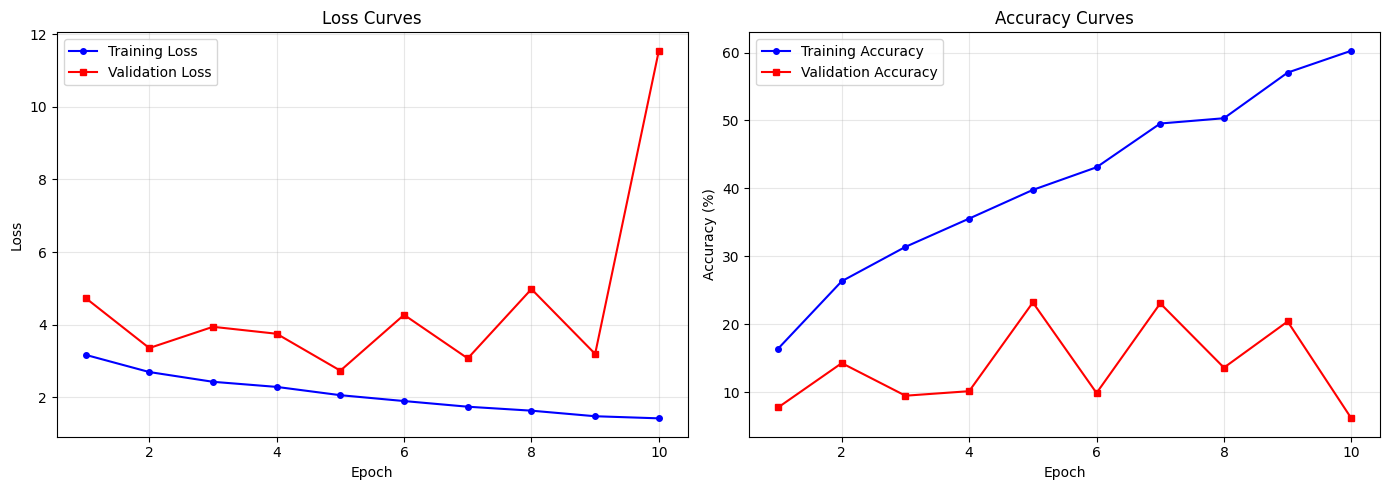

Epoch 11/50 [Val]: 100%|████████████████████████████████| 12/12 [00:05<00:00,  2.04it/s, loss=1.245]



📊 Epoch 11/50
   Train - Loss: 1.3301, Acc: 61.72%
   Val   - Loss: 5.9152, Acc: 13.47%
   Best Val Acc: 23.20%
----------------------------------------------------------------------



Epoch 12/50 [Val]: 100%|████████████████████████████████| 12/12 [00:03<00:00,  3.08it/s, loss=1.002]



📊 Epoch 12/50
   Train - Loss: 1.2171, Acc: 62.39%
   Val   - Loss: 4.0409, Acc: 20.93%
   Best Val Acc: 23.20%
----------------------------------------------------------------------



Epoch 13/50 [Val]: 100%|████████████████████████████████| 12/12 [00:05<00:00,  2.11it/s, loss=1.672]


...


📊 Epoch 18/50
   Train - Loss: 0.8957, Acc: 73.67%
   Val   - Loss: 3.1833, Acc: 25.73%
   Best Val Acc: 26.80%
----------------------------------------------------------------------



Epoch 19/50 [Val]: 100%|████████████████████████████████| 12/12 [00:05<00:00,  2.08it/s, loss=3.624]



📊 Epoch 19/50
   Train - Loss: 0.9013, Acc: 72.78%
   Val   - Loss: 8.6187, Acc: 13.20%
   Best Val Acc: 26.80%
----------------------------------------------------------------------



Epoch 20/50 [Val]: 100%|████████████████████████████████| 12/12 [00:03<00:00,  3.05it/s, loss=0.995]


🎉 New best validation accuracy: 28.9333%

📊 Epoch 20/50
   Train - Loss: 0.8502, Acc: 72.56%
   Val   - Loss: 2.9490, Acc: 28.93%
   Best Val Acc: 28.93%
----------------------------------------------------------------------



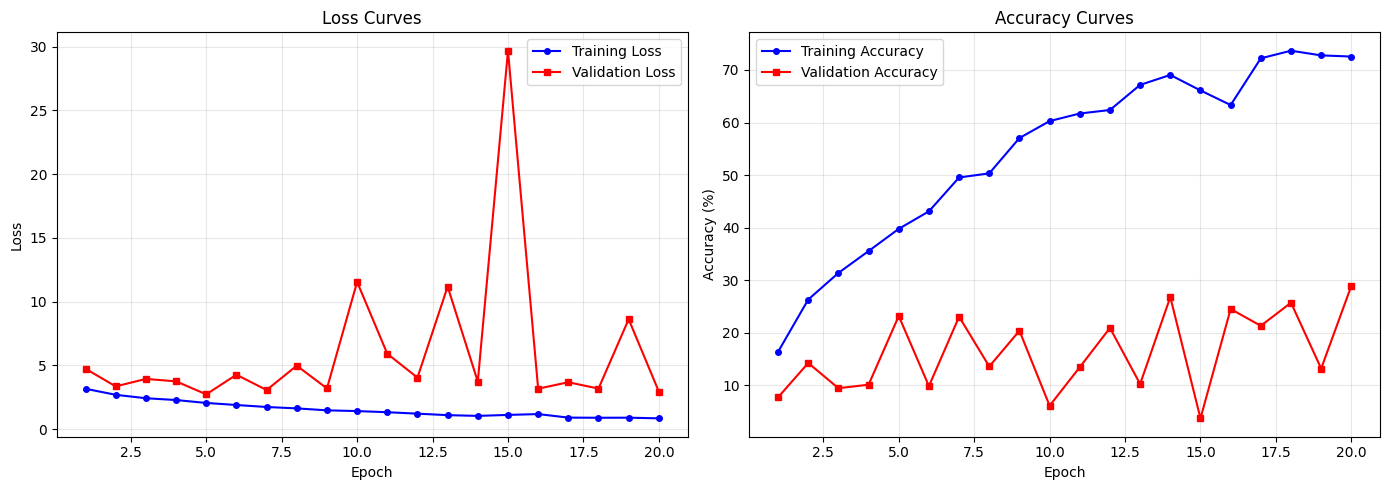

Epoch 21/50 [Val]: 100%|████████████████████████████████| 12/12 [00:04<00:00,  2.40it/s, loss=1.831]



📊 Epoch 21/50
   Train - Loss: 0.7301, Acc: 79.50%
   Val   - Loss: 18.0290, Acc: 7.87%
   Best Val Acc: 28.93%
----------------------------------------------------------------------



Epoch 22/50 [Val]: 100%|████████████████████████████████| 12/12 [00:04<00:00,  2.72it/s, loss=2.940]



📊 Epoch 22/50
   Train - Loss: 0.7402, Acc: 77.22%
   Val   - Loss: 6.8547, Acc: 14.53%
   Best Val Acc: 28.93%
----------------------------------------------------------------------



Epoch 23/50 [Val]: 100%|████████████████████████████████| 12/12 [00:03<00:00,  3.08it/s, loss=1.599]


...


📊 Epoch 28/50
   Train - Loss: 0.5353, Acc: 84.83%
   Val   - Loss: 5.5095, Acc: 17.47%
   Best Val Acc: 38.40%
----------------------------------------------------------------------



Epoch 29/50 [Val]: 100%|████████████████████████████████| 12/12 [00:04<00:00,  2.52it/s, loss=1.623]



📊 Epoch 29/50
   Train - Loss: 0.4802, Acc: 85.39%
   Val   - Loss: 4.0583, Acc: 24.27%
   Best Val Acc: 38.40%
----------------------------------------------------------------------



Epoch 30/50 [Val]: 100%|████████████████████████████████| 12/12 [00:03<00:00,  3.08it/s, loss=1.441]



📊 Epoch 30/50
   Train - Loss: 0.4775, Acc: 86.44%
   Val   - Loss: 4.9554, Acc: 24.80%
   Best Val Acc: 38.40%
----------------------------------------------------------------------



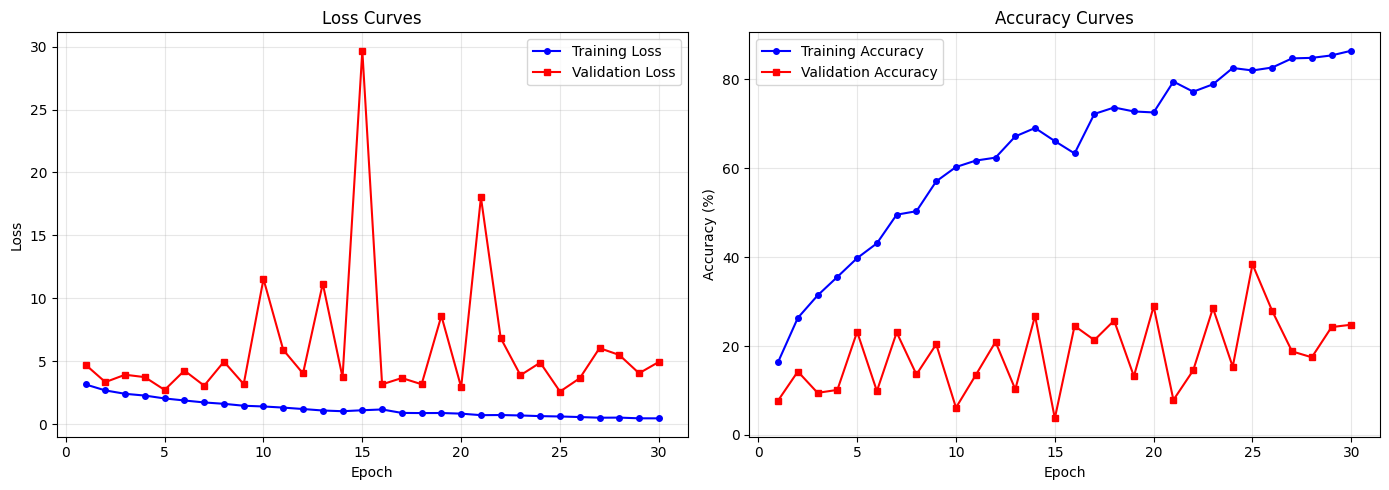

Epoch 31/50 [Val]: 100%|████████████████████████████████| 12/12 [00:05<00:00,  2.08it/s, loss=1.990]



📊 Epoch 31/50
   Train - Loss: 0.4971, Acc: 86.83%
   Val   - Loss: 3.5376, Acc: 31.20%
   Best Val Acc: 38.40%
----------------------------------------------------------------------



Epoch 32/50 [Val]: 100%|████████████████████████████████| 12/12 [00:03<00:00,  3.13it/s, loss=3.076]



📊 Epoch 32/50
   Train - Loss: 0.6220, Acc: 80.89%
   Val   - Loss: 7.6287, Acc: 14.27%
   Best Val Acc: 38.40%
----------------------------------------------------------------------



Epoch 33/50 [Val]: 100%|████████████████████████████████| 12/12 [00:04<00:00,  2.57it/s, loss=1.008]


...


📊 Epoch 38/50
   Train - Loss: 0.4094, Acc: 88.78%
   Val   - Loss: 15.0423, Acc: 10.13%
   Best Val Acc: 38.40%
----------------------------------------------------------------------



Epoch 39/50 [Val]: 100%|████████████████████████████████| 12/12 [00:05<00:00,  2.27it/s, loss=0.773]


🎉 New best validation accuracy: 44.5333%

📊 Epoch 39/50
   Train - Loss: 0.3689, Acc: 90.50%
   Val   - Loss: 2.2426, Acc: 44.53%
   Best Val Acc: 44.53%
----------------------------------------------------------------------



Epoch 40/50 [Val]: 100%|████████████████████████████████| 12/12 [00:03<00:00,  3.00it/s, loss=2.973]



📊 Epoch 40/50
   Train - Loss: 0.3309, Acc: 90.56%
   Val   - Loss: 10.0726, Acc: 14.67%
   Best Val Acc: 44.53%
----------------------------------------------------------------------



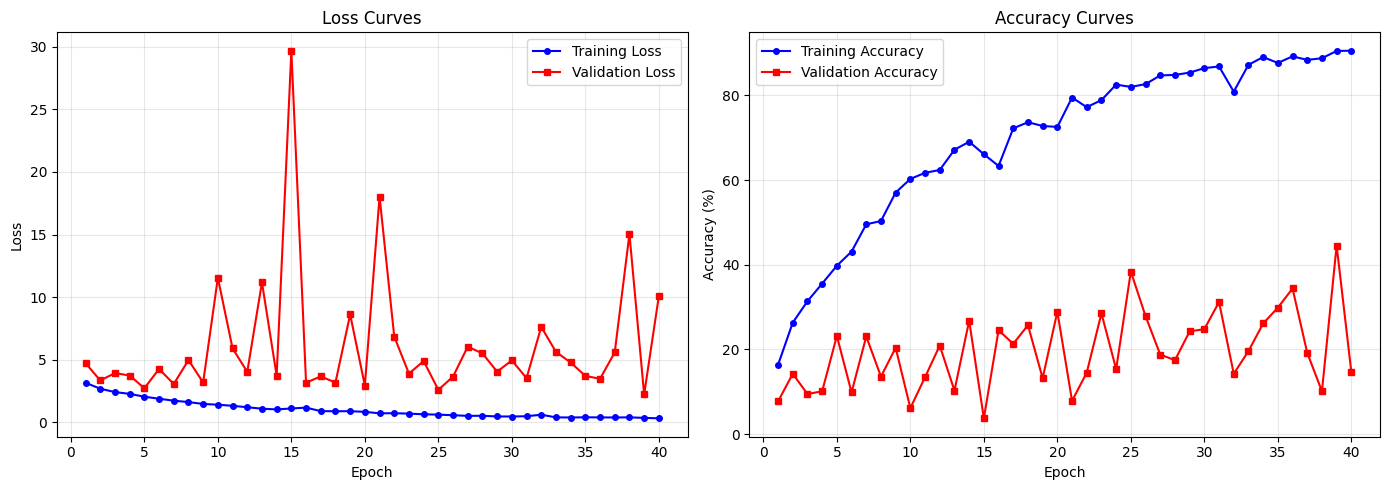

Epoch 41/50 [Val]: 100%|████████████████████████████████| 12/12 [00:05<00:00,  2.29it/s, loss=2.922]



📊 Epoch 41/50
   Train - Loss: 0.3490, Acc: 91.94%
   Val   - Loss: 8.8869, Acc: 12.93%
   Best Val Acc: 44.53%
----------------------------------------------------------------------



Epoch 42/50 [Val]: 100%|████████████████████████████████| 12/12 [00:04<00:00,  2.59it/s, loss=1.390]



📊 Epoch 42/50
   Train - Loss: 0.4709, Acc: 85.56%
   Val   - Loss: 3.7507, Acc: 31.73%
   Best Val Acc: 44.53%
----------------------------------------------------------------------



Epoch 43/50 [Val]: 100%|████████████████████████████████| 12/12 [00:04<00:00,  2.99it/s, loss=2.133]


...

🎉 New best validation accuracy: 46.2667%

📊 Epoch 48/50
   Train - Loss: 0.2514, Acc: 93.56%
   Val   - Loss: 2.2935, Acc: 46.27%
   Best Val Acc: 46.27%
----------------------------------------------------------------------



Epoch 49/50 [Val]: 100%|████████████████████████████████| 12/12 [00:05<00:00,  2.04it/s, loss=6.421]



📊 Epoch 49/50
   Train - Loss: 0.3069, Acc: 91.78%
   Val   - Loss: 8.9697, Acc: 13.87%
   Best Val Acc: 46.27%
----------------------------------------------------------------------



Epoch 50/50 [Val]: 100%|████████████████████████████████| 12/12 [00:04<00:00,  2.96it/s, loss=1.677]



📊 Epoch 50/50
   Train - Loss: 0.2582, Acc: 93.00%
   Val   - Loss: 2.7522, Acc: 41.47%
   Best Val Acc: 46.27%
----------------------------------------------------------------------



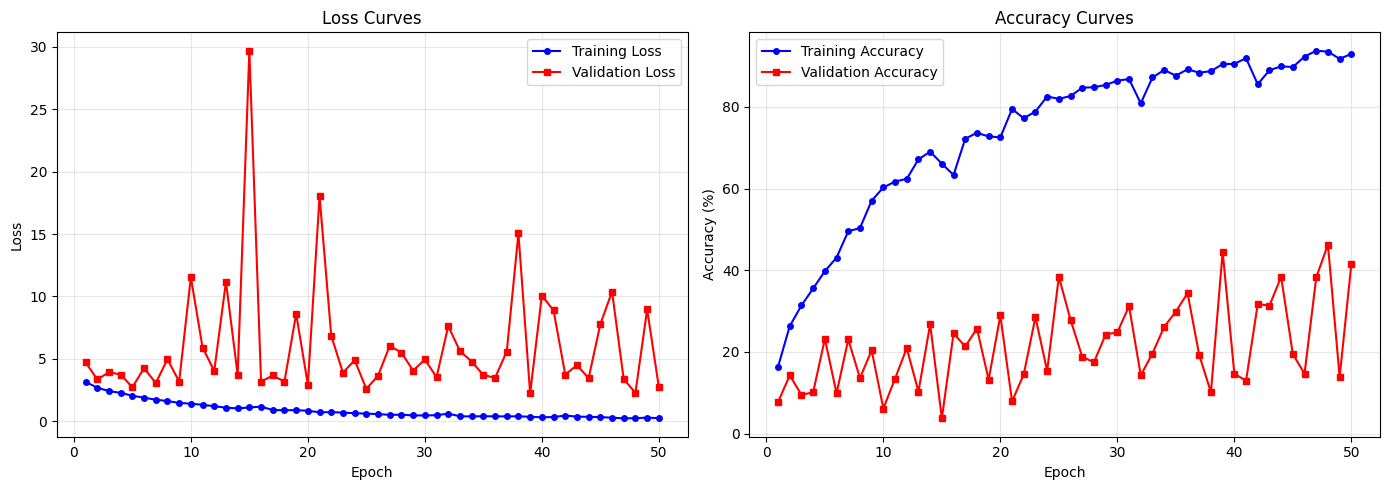

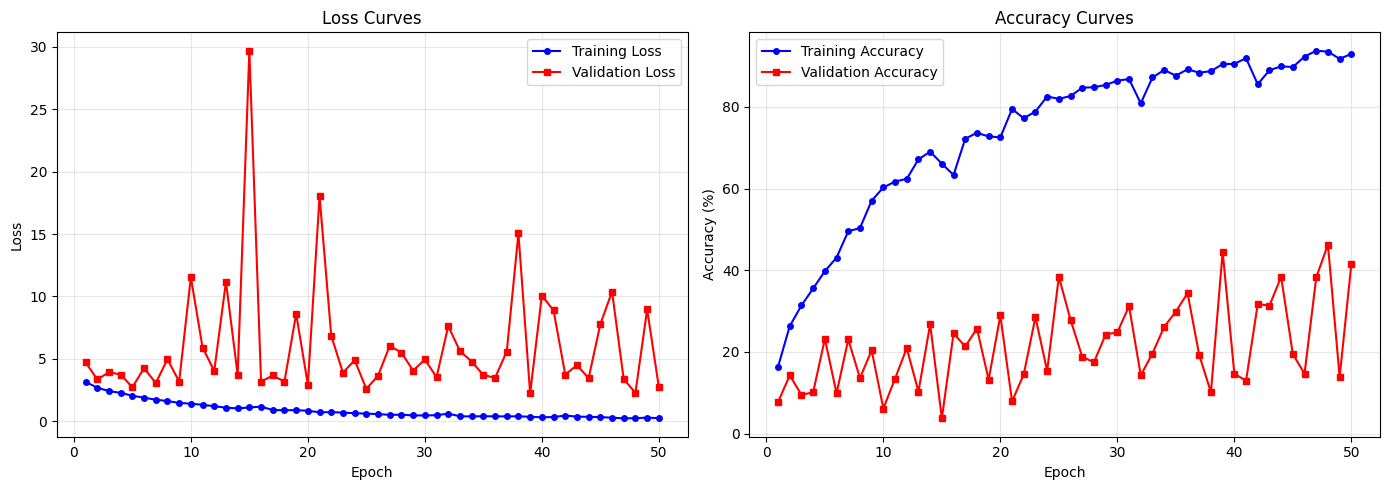


✅ Training Complete! Best Accuracy: 46.27%


In [9]:
# ============================================
# TRAINER FOR IMAGE-ONLY MODEL (2 values)
# ============================================
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

class ImageOnlyTrainer:
    def __init__(self, model, train_loader, val_loader):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        self.criterion = nn.CrossEntropyLoss()

        # Tracking metrics
        self.best_val_acc = 0
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []

    def train_epoch(self, epoch):
        """Train for one epoch with progress bar"""
        self.model.train()
        correct = 0
        total = 0
        loss_sum = 0

        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch}/{config.NUM_EPOCHS} [Train]',
                    ncols=100)

        for images, labels in pbar:  # Only 2 values: images and labels
            images = images.to(config.DEVICE)
            labels = labels.to(config.DEVICE)

            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()

            loss_sum += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            batch_acc = 100. * correct / total if total > 0 else 0
            pbar.set_postfix({'loss': f'{loss.item():.3f}', 'acc': f'{batch_acc:.2f}%'})

        avg_loss = loss_sum / len(self.train_loader)
        accuracy = 100. * correct / total
        return avg_loss, accuracy

    def validate(self, epoch):
        """Validate with progress bar"""
        self.model.eval()
        correct = 0
        total = 0
        loss_sum = 0

        pbar = tqdm(self.val_loader, desc=f'Epoch {epoch}/{config.NUM_EPOCHS} [Val]',
                    ncols=100)

        with torch.no_grad():
            for images, labels in pbar:  # Only 2 values
                images = images.to(config.DEVICE)
                labels = labels.to(config.DEVICE)

                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                loss_sum += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

                pbar.set_postfix({'loss': f'{loss.item():.3f}'})

        avg_loss = loss_sum / len(self.val_loader)
        accuracy = 100. * correct / total
        return avg_loss, accuracy

    def plot_curves(self):
        """Plot training curves"""
        epochs = range(1, len(self.train_losses) + 1)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        ax1.plot(epochs, self.train_losses, 'b-', label='Training Loss', marker='o', markersize=4)
        ax1.plot(epochs, self.val_losses, 'r-', label='Validation Loss', marker='s', markersize=4)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Loss Curves')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2.plot(epochs, self.train_accs, 'b-', label='Training Accuracy', marker='o', markersize=4)
        ax2.plot(epochs, self.val_accs, 'r-', label='Validation Accuracy', marker='s', markersize=4)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy (%)')
        ax2.set_title('Accuracy Curves')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(os.path.join(config.SAVE_DIR, 'training_curves.png'), dpi=150)
        plt.show()

    def train(self):
        """Main training loop"""
        print(f"\n{'='*70}")
        print(f"🚀 STARTING TRAINING".center(70))
        print(f"{'='*70}")
        print(f"   Total Epochs: {config.NUM_EPOCHS}")
        print(f"   Device: {config.DEVICE}")
        print(f"{'='*70}\n")

        for epoch in range(1, config.NUM_EPOCHS + 1):
            train_loss, train_acc = self.train_epoch(epoch)
            val_loss, val_acc = self.validate(epoch)

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accs.append(train_acc)
            self.val_accs.append(val_acc)

            is_best = val_acc > self.best_val_acc
            if is_best:
                self.best_val_acc = val_acc
                torch.save(self.model.state_dict(), f'{config.SAVE_DIR}/best_model.pth')
                print(f"🎉 New best validation accuracy: {val_acc:.4f}%")

            print(f"\n📊 Epoch {epoch}/{config.NUM_EPOCHS}")
            print(f"   Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
            print(f"   Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
            print(f"   Best Val Acc: {self.best_val_acc:.2f}%")
            print(f"{'-'*70}\n")

            if epoch % 10 == 0:
                self.plot_curves()

        self.plot_curves()
        print(f"\n✅ Training Complete! Best Accuracy: {self.best_val_acc:.2f}%")

# Use this trainer for image-only model
trainer = ImageOnlyTrainer(model, train_loader, val_loader)
trainer.train()

In [10]:
# Get all classes
classes = [d for d in os.listdir(config.DATASET_PATH)
               if os.path.isdir(os.path.join(config.DATASET_PATH, d))]
classes.sort()
classes

['1.Tulshi',
 '10.Jolpai',
 '11.Neem',
 '12.Joba',
 '13.Telakucha',
 '14.Noyontara',
 '15.Bongada',
 '16.Boroi',
 '17.Horitoki',
 '18.Mehedi',
 '19.Aorhor',
 '2.Pathorkuchi',
 '20.Pudina',
 '21.Thankuni',
 '22.Paharipata',
 '23.Lemon',
 '24.Dhutra',
 '25.Raktapata',
 '26.Akondo',
 '27.Karipata',
 '28.Oporajita',
 '29.Hasnahena',
 '3.Bashok',
 '30.Orjun',
 '4.Hatishur',
 '5.Goolmorich',
 '6.Togor',
 '7.Daruchini',
 '8.Tejpata',
 '9.Sofeda']

✓ Loading model from /content/leaf_classification/checkpoints/best_model.pth
✓ Loaded model (state_dict format)

📊 Evaluating on test set...


100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



📈 TEST RESULTS
Overall Accuracy: 44.67%

Classification Report:
              precision    recall  f1-score   support

           0      0.455     0.333     0.385        15
           1      1.000     0.400     0.571        15
           2      0.267     0.800     0.400        15
           3      0.000     0.000     0.000        15
           4      0.000     0.000     0.000        15
           5      1.000     0.667     0.800        15
           6      1.000     0.067     0.125        15
           7      1.000     0.067     0.125        15
           8      0.583     0.467     0.519        15
           9      0.429     0.400     0.414        15
          10      1.000     0.533     0.696        15
          11      0.341     0.933     0.500        15
          12      1.000     0.200     0.333        15
          13      0.467     0.933     0.622        15
          14      0.333     0.133     0.190        15
          15      1.000     0.067     0.125        15
          16    

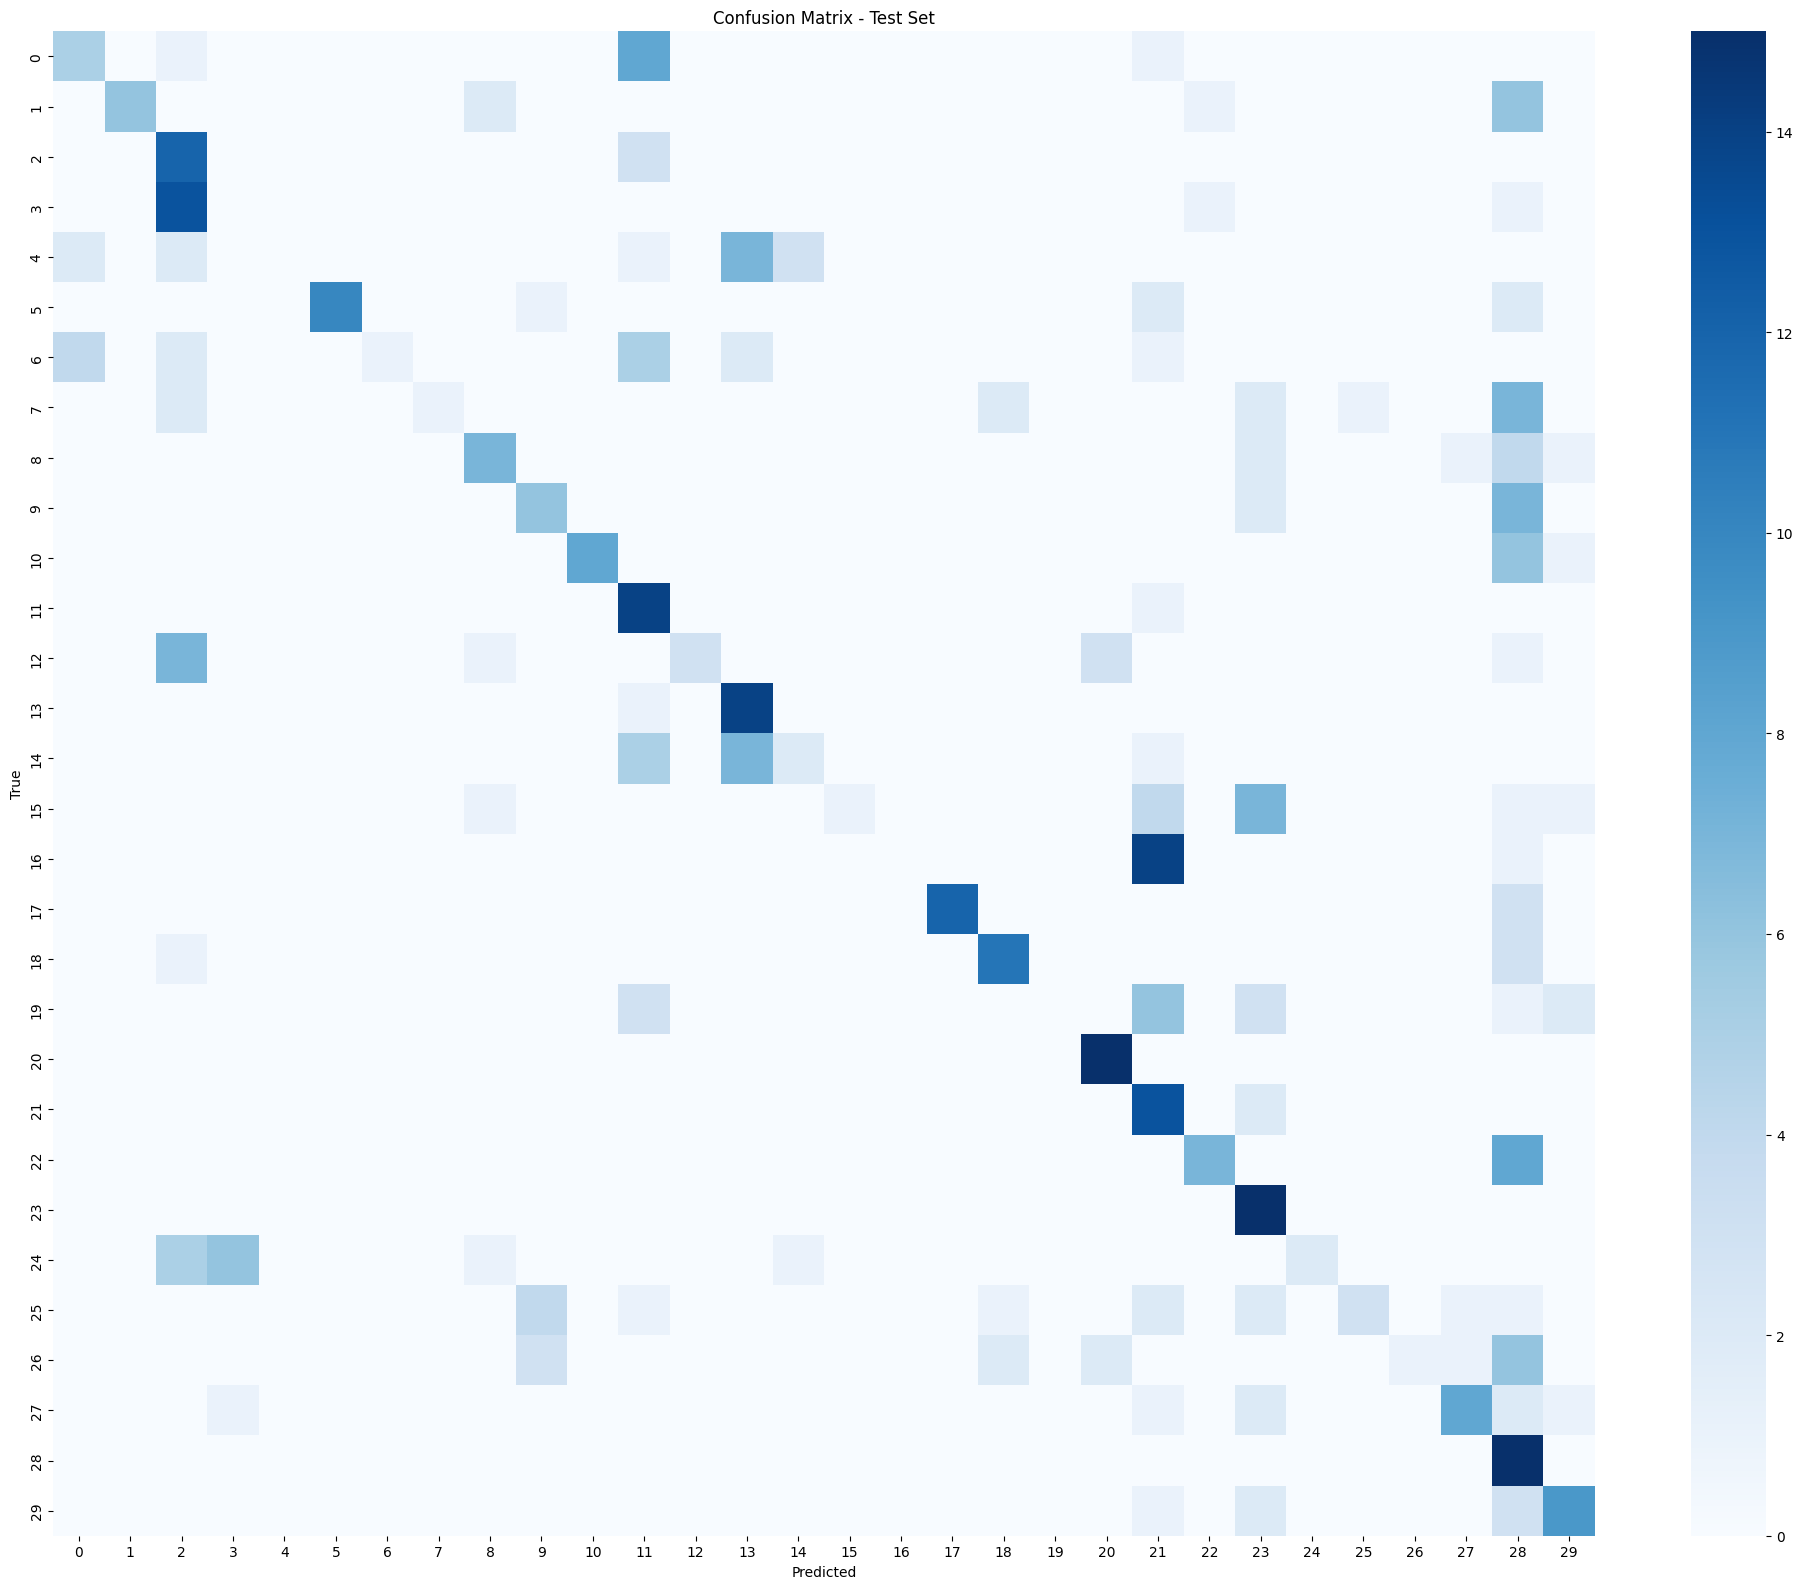


📈 PER-CLASS ACCURACY:
--------------------------------------------------------------------------------
1.Tulshi             ████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  33.3%
10.Jolpai            ████████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  40.0%
11.Neem              ████████████████████████████████████████░░░░░░░░░░  80.0%
12.Joba              ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░   0.0%
13.Telakucha         ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░   0.0%
14.Noyontara         █████████████████████████████████░░░░░░░░░░░░░░░░░  66.7%
15.Bongada           ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░   6.7%
16.Boroi             ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░   6.7%
17.Horitoki          ███████████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░  46.7%
18.Mehedi            ████████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  40.0%
19.Aorhor            ██████████████████████████░░░░░░░░░░░░░░░░░░░░░░░░  53.3%
2.Pathorkuchi        ██████

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
# ============================================
# CELL 9 (UPDATED): Evaluation on Test Set
# ============================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import torch

def evaluate_model(model, test_loader):
    """Evaluate model on test set"""
    model.eval()
    all_preds = []
    all_labels = []

    print("\n📊 Evaluating on test set...")

    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images = images.to(config.DEVICE)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Calculate metrics
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))

    print(f"\n{'='*60}")
    print(f"📈 TEST RESULTS")
    print(f"{'='*60}")
    print(f"Overall Accuracy: {accuracy*100:.2f}%")

    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(all_labels, all_preds, digits=3))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(20, 16))
    sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
    plt.title('Confusion Matrix - Test Set')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(config.SAVE_DIR, 'test_confusion_matrix.png'))
    plt.show()

    print("\n📈 PER-CLASS ACCURACY:")
    print("-"*80)
    for i, class_name in enumerate(classes):
        correct = cm[i, i]
        total = np.sum(cm[i, :])
        acc = correct / total * 100 if total > 0 else 0
        bar_length = int(acc / 2)
        bar = "█" * bar_length + "░" * (50 - bar_length) # Use 50 as max bar length
        print(f"{class_name:20} {bar} {acc:5.1f}%")


    return accuracy, all_preds, all_labels

# Load best model - FIXED VERSION
checkpoint_path = os.path.join(config.SAVE_DIR, 'best_model.pth')

if os.path.exists(checkpoint_path):
    print(f"✓ Loading model from {checkpoint_path}")

    # Try loading as state_dict first (new format)
    try:
        model.load_state_dict(torch.load(checkpoint_path, map_location=config.DEVICE))
        print("✓ Loaded model (state_dict format)")
    except:
        # Try loading as checkpoint dict (old format)
        checkpoint = torch.load(checkpoint_path, map_location=config.DEVICE)
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
            print(f"✓ Loaded model from epoch {checkpoint.get('epoch', 'unknown')}")
        else:
            print("❌ Could not load model - please retrain")
            exit()
else:
    print(f"❌ No model found at {checkpoint_path}")
    print("Please train the model first by running Cell 8")
    exit()

# Evaluate
test_acc, predictions, labels = evaluate_model(model, test_loader)

# Save test results
with open(os.path.join(config.SAVE_DIR, 'test_results.txt'), 'w') as f:
    f.write(f"Test Accuracy: {test_acc*100:.2f}%\n")
    f.write(f"\nClassification Report:\n")
    f.write(classification_report(labels, predictions))

print(f"\n✓ Results saved to {config.SAVE_DIR}/test_results.txt")